Name: S M Anik Hasan

Email: smanikhasan475@gmail.com

In [97]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer


from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score,precision_score,recall_score

from sklearn.metrics import confusion_matrix,classification_report
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.linear_model import LinearRegression,SGDRegressor
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error

In [98]:
df = pd.read_csv('adult_income.csv')
df.sample(10)

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
9780,49,Federal-gov,105586,Assoc-voc,11,Married-civ-spouse,Craft-repair,Husband,Asian-Pac-Islander,Male,0,0,40,United-States,>50K
3322,37,Private,409189,Some-college,10,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,45,United-States,<=50K
19566,54,Private,82566,Assoc-acdm,12,Married-civ-spouse,Sales,Husband,White,Male,0,0,45,United-States,<=50K
4644,35,Local-gov,185769,Some-college,10,Married-civ-spouse,Other-service,Husband,White,Male,0,0,40,United-States,<=50K
43151,36,Private,110013,Masters,14,Never-married,Sales,Not-in-family,White,Female,0,0,40,United-States,<=50K.
43593,55,Private,202435,Bachelors,13,Divorced,Adm-clerical,Not-in-family,White,Female,0,0,40,United-States,<=50K.
15310,19,?,109938,11th,7,Married-civ-spouse,?,Wife,Asian-Pac-Islander,Female,0,0,40,Laos,<=50K
26863,37,Self-emp-inc,86459,Assoc-acdm,12,Separated,Exec-managerial,Unmarried,White,Male,0,0,50,United-States,<=50K
18839,66,Self-emp-not-inc,174995,Assoc-acdm,12,Married-civ-spouse,Craft-repair,Husband,White,Male,2290,0,30,Hungary,<=50K
35192,33,Private,143485,HS-grad,9,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K.


##Q1:

In [99]:
df.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


In [100]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             48842 non-null  int64 
 1   workclass       48842 non-null  object
 2   fnlwgt          48842 non-null  int64 
 3   education       48842 non-null  object
 4   education-num   48842 non-null  int64 
 5   marital-status  48842 non-null  object
 6   occupation      48842 non-null  object
 7   relationship    48842 non-null  object
 8   race            48842 non-null  object
 9   sex             48842 non-null  object
 10  capital-gain    48842 non-null  int64 
 11  capital-loss    48842 non-null  int64 
 12  hours-per-week  48842 non-null  int64 
 13  native-country  48842 non-null  object
 14  income          48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


In [101]:
num_f = df.select_dtypes(include=['int64','float64']).columns
print(num_f)
cat_f = df.select_dtypes(include=['object']).columns
print(cat_f)

Index(['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss',
       'hours-per-week'],
      dtype='object')
Index(['workclass', 'education', 'marital-status', 'occupation',
       'relationship', 'race', 'sex', 'native-country', 'income'],
      dtype='object')


In [102]:
df['income'] = df['income'].str.replace('.', '', regex=False)    #to remove only dot(50K.) regex=False is used

In [103]:
df['income'].value_counts()

,count
income,
<=50K,37155
>50K,11687


##EDA of Numerical data

Text(0.5, 0.98, 'Distributions of Numerical Features')

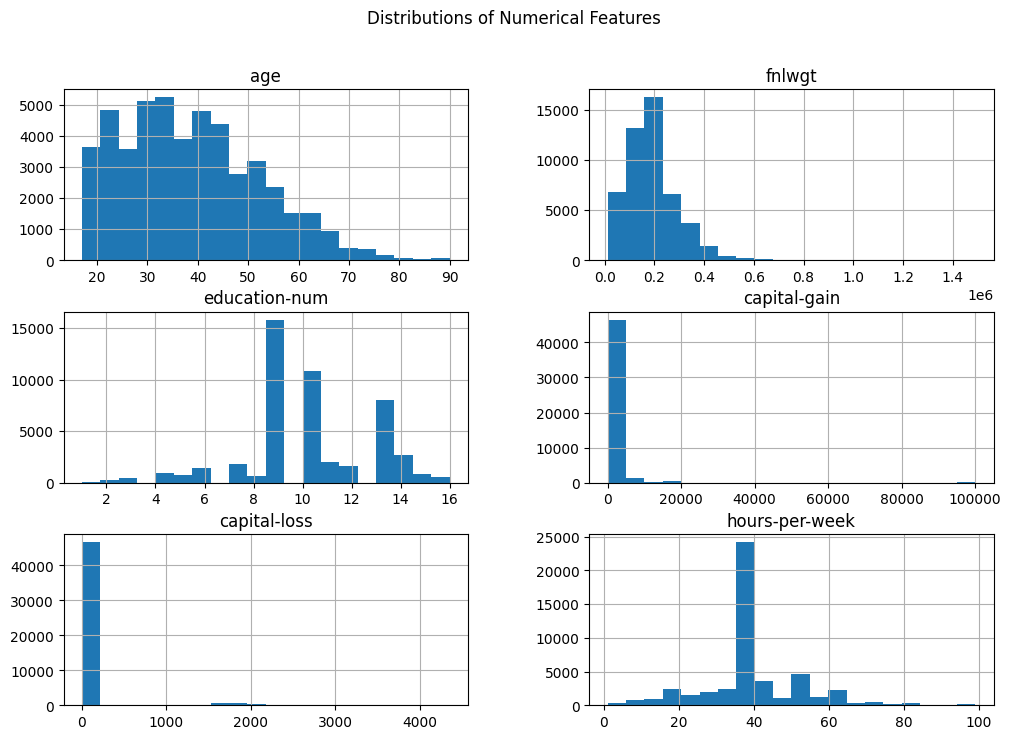

In [104]:
df.hist(figsize=(12,8),bins=20)
plt.suptitle("Distributions of Numerical Features")

<Axes: >

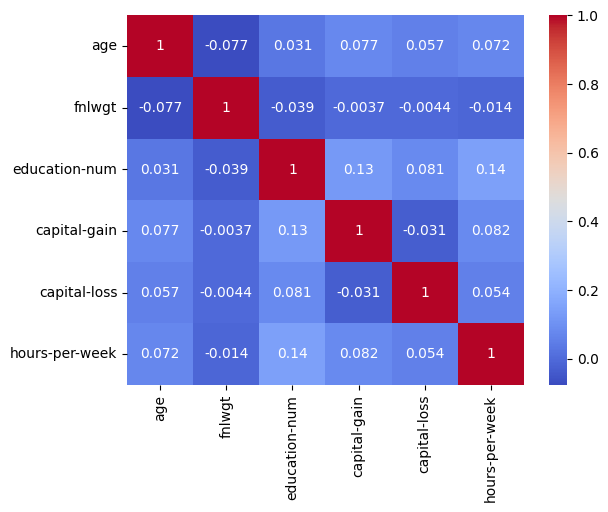

In [105]:
sns.heatmap(
    df.select_dtypes(include=['int64','float64']).corr(),
    annot=True,
    cmap='coolwarm'
)


By the heatmap, there is no significant relation/ratio of the aforementioned couple.

<Axes: xlabel='education-num', ylabel='income'>

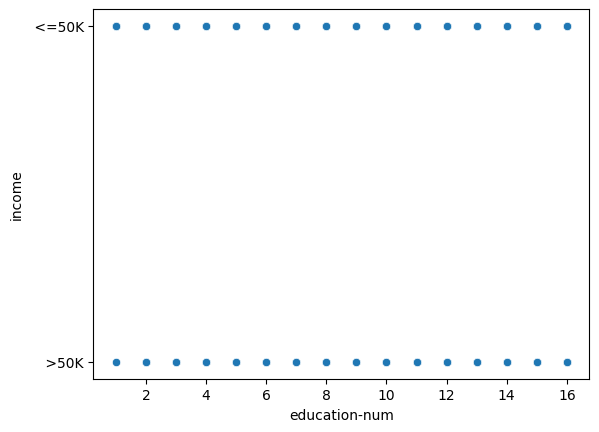

In [106]:
sns.scatterplot(data=df,y='income',x='education-num')

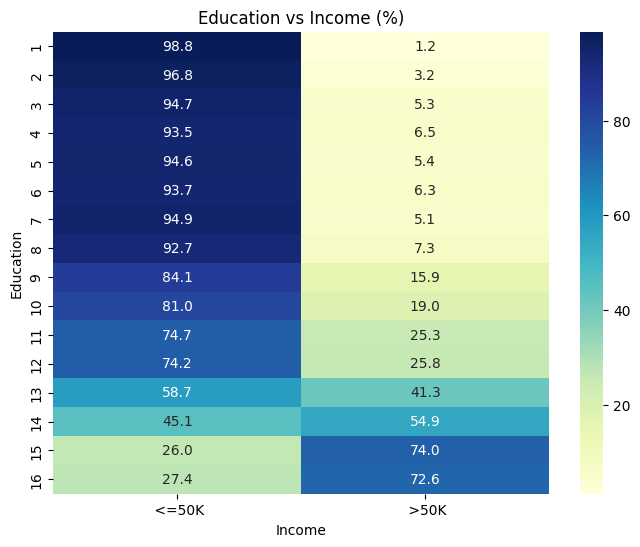

In [107]:
#Implement this map by the help of chatgpt and w3 school
edu_income = pd.crosstab(
    df['education-num'],
    df['income'],
    normalize='index'
) * 100

plt.figure(figsize=(8,6))
sns.heatmap(edu_income, annot=True, fmt='.1f', cmap='YlGnBu')

plt.title('Education vs Income (%)')
plt.xlabel('Income')
plt.ylabel('Education')
plt.show()

By that crosstab heatmap, we can clearly see that income is portional to the level of education. Possibility of getting more than 50k is depend on the higher level education/education-num.

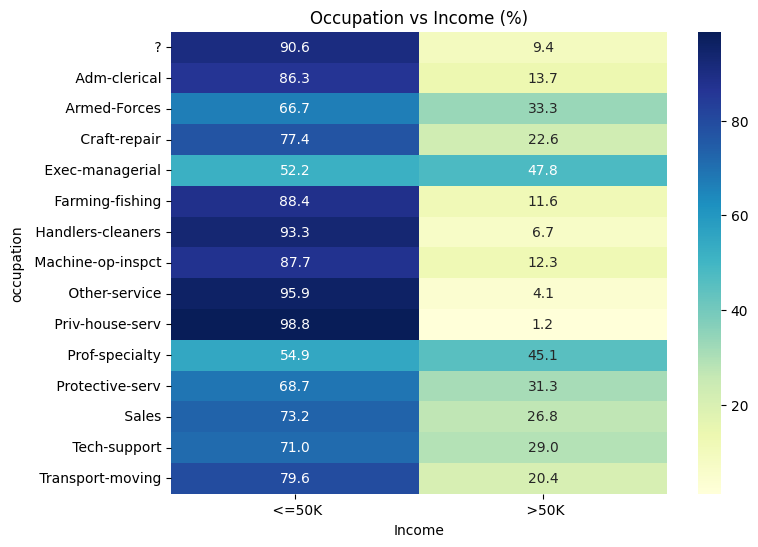

In [108]:

edu_income = pd.crosstab(
    df['occupation'],
    df['income'],
    normalize='index'
) * 100

plt.figure(figsize=(8,6))
sns.heatmap(edu_income, annot=True, fmt='.1f', cmap='YlGnBu')

plt.title('Occupation vs Income (%)')
plt.xlabel('Income')
plt.ylabel('occupation')
plt.show()

By the crosstab,we can say that income is different by the level of job quality like the percentage of earning more than 50k for Prof-specialty is 45.1 whereas for Priv-house-serv is only 1.2

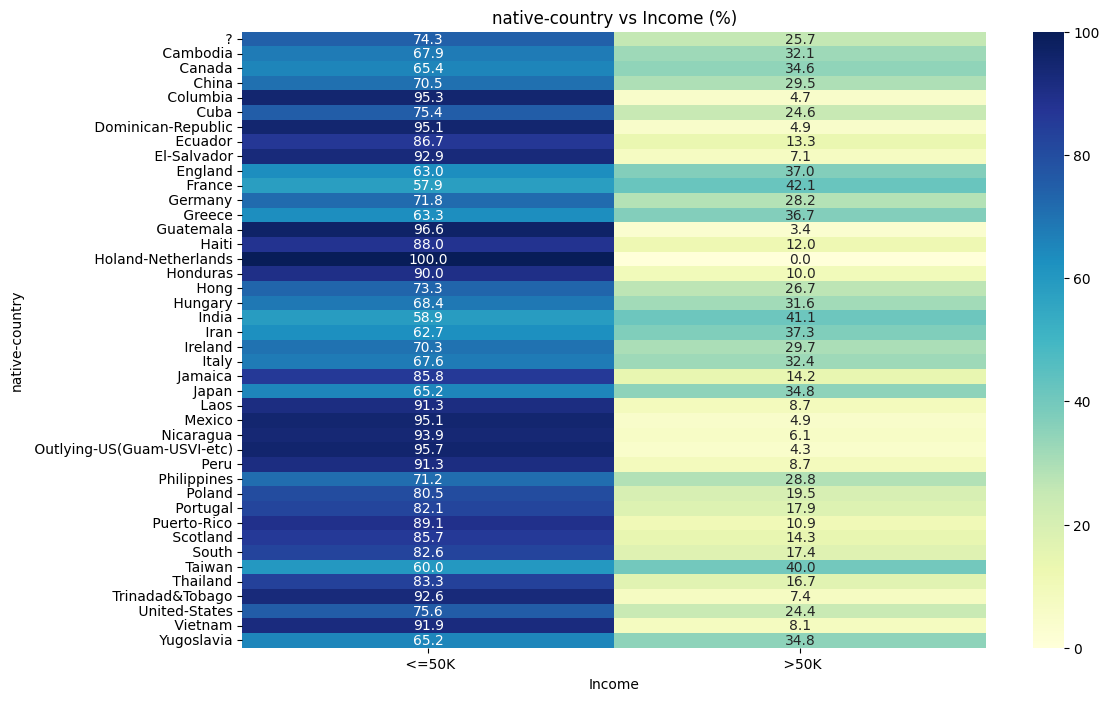

In [109]:

edu_income = pd.crosstab(
    df['native-country'],
    df['income'],
    normalize='index'
) * 100

plt.figure(figsize=(12,8))
sns.heatmap(edu_income, annot=True, fmt='.1f', cmap='YlGnBu')

plt.title('native-country vs Income (%)')
plt.xlabel('Income')
plt.ylabel('native-country')
plt.show()

The doller-rate is different by country stat. In a higher doller rated country people can earn more than 50k though his/her education-num or job quality is lower than the other country. So income is greatly depent on it.

Rank my 3 features from most important to least important:
education-num > native-country > occupation

In my side of view,Education-num should be placed at the top because a more educated people have more options to switched their job for earning good.

After that, native-country is more concern issue than the occupation as i previously mentioned that a man can earn >50k by doing a lower grade job because of the doller rate.

##Q2:


In [110]:
df.isnull().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,0
relationship,0
race,0
sex,0


<Axes: xlabel='capital-loss'>

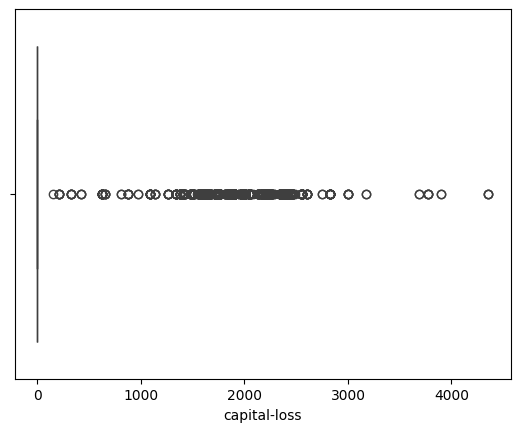

In [111]:
sns.boxplot(data=df , x="capital-loss")

In [112]:
X = df.drop(['hours-per-week'],axis=1)
y = df['hours-per-week']
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [113]:
num_f_new = X.select_dtypes(include=['int64', 'float64']).columns
cat_f = X.select_dtypes(include=['object']).columns

<Axes: xlabel='hours-per-week', ylabel='Count'>

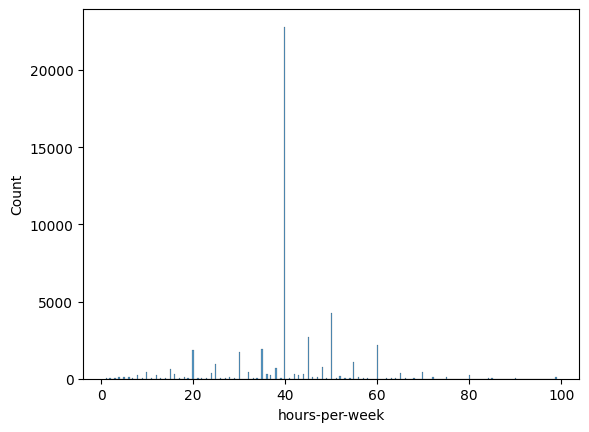

In [114]:
sns.histplot(data=df, x='hours-per-week')

In [115]:
numerical_transformer = Pipeline(
    steps = [
        ("imputer", SimpleImputer(strategy = 'median')),
        ("scaler", StandardScaler())
    ]
)
numerical_transformer

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())])

In [116]:
categorical_transformer = Pipeline(
    steps = [
        ("imputer",SimpleImputer(strategy= 'most_frequent')),
        ("encoding",OneHotEncoder(handle_unknown = 'ignore'))
    ]
)
categorical_transformer

Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                ('encoding', OneHotEncoder(handle_unknown='ignore'))])

In [117]:
from sklearn.preprocessing import RobustScaler
robust_transformer = Pipeline(
    steps = [
        ("imputer", SimpleImputer(strategy = 'median')),
        ("scaler", RobustScaler())
    ]
)
robust_transformer

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', RobustScaler())])

In [118]:
preprocessor = ColumnTransformer(
    transformers = [
        ("Numerical",numerical_transformer,num_f_new),
        ("Categorical",categorical_transformer,cat_f),
        ("Outlier_feature",robust_transformer,["capital-loss"])
    ]
)
preprocessor

ColumnTransformer(transformers=[('Numerical',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 Index(['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss'], dtype='object')),
                                ('Categorical',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoding',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 Index(['workclass', 'education', 'marital-status', 'occupation',
       'relationship', 'race', 'sex', 'native-country', 'income'],
      dtype='object')),
                                ('Outlier_feature',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', RobustScaler())]),
                                 ['capital-loss'])])

As there is no missing value in the dataframe, we can use SimpleImputer by default.

From the solution of Q1, the histplot of numerical dataset that overall there is no outlier and data is normally distributed except capital loss column so we can use StandardScaler.

By the box plot of Capital-loss, there are shown outliers. So RobustScaler will be better for this feature to scale.

As there is no ordinal feature that's why OneHotEncoder is used to encode. (df['education'] is already encoded as df['education-num'])

##Q3:

In [119]:
y

,hours-per-week
0,40
1,13
2,40
3,40
4,40
...,...
48837,36
48838,40
48839,50
48840,40


In [120]:
lr_model = Pipeline(
    steps=[
        ('preprocessor',preprocessor),
        ('model',LinearRegression())
    ]
)
lr_model
lr_model.fit(X_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('Numerical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss'], dtype='object')),
                                                 ('Categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoding',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['workclass', 'education', 'marital-status', 'occupation',
       'relationship', 'race', 'sex', 'native-country', 'income'],
      dtype='object')),
                                                 ('Outlier_feature',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   RobustScaler())]),
                                                  ['capital-loss'])])),
                ('model', LinearRegression())])

In [121]:
lr_model.predict(X_test)

array([39.7762024 , 30.76189801, 38.50909643, ..., 46.94646272,
       45.91352137, 45.19831906])

In [122]:

SGD_pipe=Pipeline(
    steps=[
        ('preprocessor',preprocessor),
        ('model' , SGDRegressor())
    ]
)


SGD_pipe.fit(X_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('Numerical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss'], dtype='object')),
                                                 ('Categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoding',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['workclass', 'education', 'marital-status', 'occupation',
       'relationship', 'race', 'sex', 'native-country', 'income'],
      dtype='object')),
                                                 ('Outlier_feature',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   RobustScaler())]),
                                                  ['capital-loss'])])),
                ('model', SGDRegressor())])

In [123]:
SGD_pipe.predict(X_train)

array([-4.95525218e+09, -5.40740548e+09, -1.24672753e+09, ...,
        2.40561830e+09, -3.51326926e+08,  1.66808179e+09])

In [124]:
def evaluate(model, name):

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    print(f"\n{name}")
    print("-"*40)

    print("Train R2 :", round(r2_score(y_train, train_pred),4))
    print("Test R2  :", round(r2_score(y_test, test_pred),4))
    print("RMSE     :", round(np.sqrt(mean_squared_error(y_test, test_pred)),4))
    print("MAE      :", round(mean_absolute_error(y_test, test_pred),4))

    return (
        r2_score(y_test, test_pred),
        np.sqrt(mean_squared_error(y_test, test_pred)),
        mean_absolute_error(y_test, test_pred)
    )

In [125]:
lr_r2 ,lr_rmse,lr_mase = evaluate(
    lr_model,
    "Linear Regression"
)
print(lr_r2 ,lr_rmse,lr_mase)


Linear Regression
----------------------------------------
Train R2 : 0.1989
Test R2  : 0.2013
RMSE     : 11.0659
MAE      : 7.6589
0.20130623009529058 11.065899336181646 7.658912313799921


In [126]:
sgd_r2 ,sgd_rmse,sgd_mase = evaluate(
    SGD_pipe,
    "sgd Regression"
)
print(sgd_r2 ,sgd_rmse,sgd_mase)


sgd Regression
----------------------------------------
Train R2 : -3.1792004043458893e+24
Test R2  : -3.202962367622354e+24
RMSE     : 22160139238334.234
MAE      : 4744422479135.55
-3.202962367622354e+24 22160139238334.234 4744422479135.55


Linear Regression achieved a positive R² score (~0.20) on both training and testing datasets, indicating that it explains about 20% of the variance in the target variable. It also produced relatively low RMSE and MAE values, showing reasonable prediction accuracy.
SGD Regression performed extremely poorly, with a very large negative R² score and enormous error values. A negative R² indicates that the model performs worse than simply predicting the mean of the target variable. This suggests that the SGD model failed to converge properly, likely due to unsuitable hyperparameters such as the learning rate (eta0), insufficient scaling, or an inappropriate optimization setup.

**Linear Regression is the better-performing model** because it achieved higher R² scores and substantially lower prediction errors. The poor performance of SGD Regression indicates convergence issues, making its predictions unreliable for this dataset.

##Q4:

In [184]:
sample_df = df.sample(n=10000, random_state=42)
x = sample_df.drop(['income'],axis=1)
Y = sample_df['income']
x_train,x_test,Y_train,Y_test = train_test_split(x,Y,test_size=0.2,random_state=42)

In [185]:
num_knn = x.select_dtypes(include=['int64', 'float64']).columns
cat_knn = x.select_dtypes(include=['object']).columns

In [186]:
preprocessor_knn = ColumnTransformer(
    transformers = [
        ("Numerical",numerical_transformer,num_knn),
        ("Categorical",categorical_transformer,cat_knn),
        ("Outlier_feature",robust_transformer,["capital-loss"])
    ]
)
preprocessor_knn

ColumnTransformer(transformers=[('Numerical',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 Index(['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss',
       'hours-per-week'],
      dtype='object')),
                                ('Categorical',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoding',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 Index(['workclass', 'education', 'marital-status', 'occupation',
       'relationship', 'race', 'sex', 'native-country'],
      dtype='object')),
                                ('Outlier_feature',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', RobustScaler())]),
                                 ['capital-loss'])])

In [187]:
knn_model= Pipeline(
    steps=[
        ('preprocessor', preprocessor_knn),
        ('model',KNeighborsClassifier(n_neighbors=3,metric='minkowski',p=2))
    ]
)


In [188]:
knn_model.fit(x_train,Y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('Numerical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss',
       'hours-per-week'],
      dtype='object')),
                                                 ('Categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent...
                                                                  ('encoding',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['workclass', 'education', 'marital-status', 'occupation',
       'relationship', 'race', 'sex', 'native-country'],
      dtype='object')),
                                                 ('Outlier_feature',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   RobustScaler())]),
                                                  ['capital-loss'])])),
                ('model', KNeighborsClassifier(n_neighbors=3))])

In [189]:
y_pred = knn_model.predict(x_test)
print(y_pred)

[0 0 0 ... 0 1 0]


In [190]:
accuracy = accuracy_score(Y_test,y_pred)
print(accuracy)

0.8245


In [191]:
recall = recall_score(Y_test,y_pred,average='weighted')
print(recall)


0.8245


In [192]:
precision = precision_score(Y_test,y_pred,average='weighted')
print(precision)

0.8196394268774704


##Q5:

In [193]:
grid = {
    'model__n_neighbors': range(3,30),
    'model__p' : [1,2]

}

grid_cv = GridSearchCV(
    estimator=knn_model,
    param_grid=grid,
    cv=5
)


In [194]:
grid_cv.fit(x_train,Y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('Numerical',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         Index(['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss',
       'hours-per-week'],
      dtype='object')),
                                                                        ('Categorical',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImp...
                                                                         Index(['workclass', 'education', 'marital-status', 'occupation',
       'relationship', 'race', 'sex', 'native-country'],
      dtype='object')),
                                                                        ('Outlier_feature',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          RobustScaler())]),
                                                                         ['capital-loss'])])),
                                       ('model',
                                        KNeighborsClassifier(n_neighbors=3))]),
             param_grid={'model__n_neighbors': range(3, 30),
                         'model__p': [1, 2]})

In [198]:
grid_cv.best_params_



{'model__n_neighbors': 23, 'model__p': 2}

In [199]:
best_model = grid_cv.best_estimator_

In [200]:
y_predict = best_model.predict(x_test)
print(y_predict)

[0 0 0 ... 0 1 0]


In [201]:
accuracy = accuracy_score(Y_test,y_predict)
print(accuracy)



0.834


In [202]:
recall = recall_score(Y_test,y_predict,average='weighted')
print(recall)

0.834


In [203]:
precision = precision_score(Y_test,y_predict,average='weighted')
print(precision)

0.8268389798943409


The Tuned KNN model showed slightly better performance than the default Logistic Regression model on the sampled dataset of 1000 observations. Since KNN generally benefits from having more training data, its performance could potentially improve further if the full dataset were used. Therefore, it is reasonable to expect that the Tuned KNN model may achieve even better results when trained and evaluated on the complete dataset.